# Event-Driven Congestion: Impact Prediction & Resource Allocation

**Objective:**
This notebook analyzes traffic event data to forecast the congestion impact of both planned and unplanned events. We derive a synthetic `Impact Score` and map it to optimal resource requirements (manpower, barricades) using an Operations Research heuristics matrix.

## Data Loading & Preprocessing
1. Read the dataset
2. Handle Missing/Invalid Timestamps
3. Calculate Event Duration
4. Compute Synthetic Impact Score based on Duration, Priority, and Road Closure.


In [1]:
!pip install shap "xgboost<2.1.0" -q
import shap

c:\Anaconda\envs\myenv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

data_path = "dataset/Astram event data_anonymized - Astram event data_anonymizedb40ac87.csv"

# Load the data
df = pd.read_csv(data_path)
print(f"Dataset loaded with shape: {df.shape}")

# Filter relevant columns
cols_to_keep = [
    'id', 'event_type', 'latitude', 'longitude', 'address', 'event_cause',
    'requires_road_closure', 'start_datetime', 'closed_datetime', 'end_datetime', 'priority', 'veh_type', 'description', 'zone', 'corridor'
]
cols_present = [c for c in cols_to_keep if c in df.columns]
df = df[cols_present]
df.head(3)

Dataset loaded with shape: (8173, 46)


,id,event_type,latitude,longitude,address,event_cause,requires_road_closure,start_datetime,closed_datetime,end_datetime,priority,veh_type,description,zone,corridor
0,FKID000000,unplanned,13.040004,77.518099,"Mumbai Bengaluru Highway, Jalahalli Cross Junc...",vehicle_breakdown,False,2024-03-07 17:01:48.111+00,NaN,NaN,High,lcv,s m circle in coming man track,NaN,Tumkur Road
1,FKID000001,unplanned,12.921876,77.645158,"19th Main Road, Heavie Halcyon, Agara, HSR Lay...",vehicle_breakdown,False,2024-01-30 04:07:24.173+00,NaN,NaN,High,heavy_vehicle,Starting problem,NaN,ORR East 1
2,FKID000002,unplanned,12.955622,77.585708,"Lalbagh Main Road, Dr Sri Shantaveera Swami Ci...",others,False,2023-11-11 06:18:03.343+00,2024-01-30 04:56:03.281509+00,NaN,Low,NaN,ಊರ್ವಶಿ ಜಂಕ್ಷನ್ ನಲ್ಲಿ ಒಳಚರಂಡಿ ಚೇಂಬರ್ ಗೆ ಹೊಸದಾಗಿ...,Central Zone 2,Non-corridor


## Target Variable Engineering: Synthetic Impact Score
Since there is no direct label for "congestion severity", we formulate an impact score proxy based on:
`Impact = f(Duration, Priority, Road Closure)`


In [3]:
# 1. Time Processing & Coalesce (End datetime for planned, closed datetime for unplanned)
df['start_datetime'] = pd.to_datetime(df['start_datetime'], errors='coerce', utc=True)
df['closed_datetime'] = pd.to_datetime(df['closed_datetime'], errors='coerce', utc=True)
df['end_datetime'] = pd.to_datetime(df['end_datetime'], errors='coerce', utc=True)

df['resolved_time'] = df['closed_datetime'].fillna(df['end_datetime'])

# Drop rows where we can't calculate duration
df = df.dropna(subset=['start_datetime', 'resolved_time']).copy()

# Calculate duration in minutes
df['duration_mins'] = (df['resolved_time'] - df['start_datetime']).dt.total_seconds() / 60.0

# Keep physically plausible events (0 to 1 week)
df = df[(df['duration_mins'] >= 0) & (df['duration_mins'] <= 10080)].copy()

# Clean spatial coordinates
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)].copy()
df = df.dropna(subset=['latitude', 'longitude']).copy()

# Calculate Spatial-Temporal Concurrent Overlapping Load (Real-time signal)
def haversine_np(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(np.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = np.sin(dlat/2.0)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2.0)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return 6367 * c

lats = df['latitude'].values
lons = df['longitude'].values
starts = df['start_datetime'].values
resolveds = df['resolved_time'].values
n = len(df)
active_loads = [np.sum(haversine_np(lons[i], lats[i], lons[(starts <= starts[i]) & (resolveds >= starts[i])], lats[(starts <= starts[i]) & (resolveds >= starts[i])]) <= 5.0) - 1 for i in range(n)]
df['nearby_active_events'] = active_loads

# Encode event_type
df['event_type_planned'] = (df['event_type'].str.lower() == 'planned').astype(int)

# 2. Priority Processing (High=3, Medium=2, Low=1)
def map_priority(p):
    p = str(p).lower()
    if 'high' in p: return 3
    if 'medium' in p: return 2
    if 'low' in p: return 1
    return 1 # Default

df['priority_score'] = df['priority'].apply(map_priority)

# 3. Road Closure Processing (Closure=1.5x penalty)
df['requires_road_closure'] = df['requires_road_closure'].fillna(False).astype(bool)
df['closure_multiplier'] = np.where(df['requires_road_closure'], 1.5, 1.0)

# 4. Save Target bounds for post-model business rules scaling
df['raw_impact'] = df['duration_mins'] * df['priority_score'] * df['closure_multiplier']
df['log_impact'] = np.log1p(df['raw_impact'])
min_impact, max_impact = df['log_impact'].min(), df['log_impact'].max()
df['impact_score'] = 1 + 9 * ((df['log_impact'] - min_impact) / (max_impact - min_impact + 1e-9))

print(f"Data set filtered to {len(df)} rows.")
print("Duration distribution (mins):")
print(df['duration_mins'].describe())

Data set filtered to 2994 rows.
Duration distribution (mins):
count     2994.000000
mean       557.617600
std       1556.733727
min          0.028550
25%         24.394343
50%         56.543860
75%        124.466736
max      10024.195977
Name: duration_mins, dtype: float64


## Spatial & Temporal Feature Engineering
1. **Temporal Features**: Extract Hour, Day of Week, and determine if the event occurred during Peak Hours.
2. **Spatial Features**: Use K-Means clustering on Latitude/Longitude to automatically identify geographic "hotspot" clusters without needing manual zone mapping.


In [4]:
from sklearn.cluster import KMeans

# 1. Temporal Features
df['hour'] = df['start_datetime'].dt.hour
df['day_of_week'] = df['start_datetime'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].isin([5, 6]).astype(int)

# Define peak hours (e.g., 8-11 AM and 5-8 PM)
def is_peak_hour(h):
    if (8 <= h <= 11) or (17 <= h <= 20):
        return 1
    return 0

df['is_peak_hour'] = df['hour'].apply(is_peak_hour)

# 2. Spatial Clustering (Finding Hotspots)
# Drop rows with missing or zero coordinates
df = df[(df['latitude'] != 0) & (df['longitude'] != 0)].copy()
df = df.dropna(subset=['latitude', 'longitude']).copy()

# Fit KMeans (we use 20 clusters for a major city)
kmeans = KMeans(n_clusters=20, random_state=42, n_init=10)
df['hotspot_cluster'] = kmeans.fit_predict(df[['latitude', 'longitude']])

print("Temporal and Spatial features generated successfully.")
display(df[['start_datetime', 'hour', 'is_peak_hour', 'latitude', 'longitude', 'hotspot_cluster']].head())


Temporal and Spatial features generated successfully.


,start_datetime,hour,is_peak_hour,latitude,longitude,hotspot_cluster
3,2024-03-07 17:56:55.061000+00:00,17,1,13.006147,77.579435,0
4,2024-01-30 04:56:32.348000+00:00,4,0,12.953980,77.585233,8
10,2024-03-07 18:01:40.182000+00:00,18,1,13.000846,77.681371,4
18,2024-03-07 19:39:29.764000+00:00,19,1,12.923352,77.590488,14
20,2024-03-07 19:25:04.302000+00:00,19,1,12.907122,77.628640,3


## Impact Predictor Model (XGBoost) & Resource Recommendation

Now that we have successfully engineered spatial, temporal, and severity features, we will build the core AI models:
1. **Predictive Engine**: An XGBoost Regressor to forecast the `Impact_Score` based on the event's initial parameters.
2. **Prescriptive Engine (Resource Recommender)**: A heuristic optimization matrix that takes the predicted impact and road closure requirements to output explicit Manpower, Barricading, and Diversion plans.


In [6]:
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, VotingRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
import pandas as pd
import warnings
import dataclasses
warnings.filterwarnings('ignore')

# Sklearn 1.6+ compatibility patch for XGBoost
if hasattr(xgb.XGBRegressor, '__sklearn_tags__'):
    orig_tags_method = xgb.XGBRegressor.__sklearn_tags__
    def patched_sklearn_tags(self):
        return dataclasses.replace(orig_tags_method(self), estimator_type="regressor")
    xgb.XGBRegressor.__sklearn_tags__ = patched_sklearn_tags

# 1. Feature Engineering for Modeling

# A. Categorical Encoding (event_cause, veh_type, zone, corridor)
df['veh_type'] = df['veh_type'].fillna('unknown')
df['zone'] = df['zone'].fillna('unknown')
df['corridor'] = df['corridor'].fillna('unknown')

df_model = pd.get_dummies(df, columns=['event_cause', 'veh_type', 'zone', 'corridor'], drop_first=True)

# B. NLP on Description
print("Extracting NLP features from Incident Descriptions...")
df_model['description'] = df_model['description'].fillna('')
tfidf = TfidfVectorizer(max_features=50, stop_words='english')
desc_tfidf = tfidf.fit_transform(df_model['description']).toarray()
tfidf_cols = [f'tfidf_{i}' for i in range(desc_tfidf.shape[1])]
df_tfidf = pd.DataFrame(desc_tfidf, columns=tfidf_cols, index=df_model.index)
df_model = pd.concat([df_model, df_tfidf], axis=1)

# Define Features (X) and Target (y)
base_features = [
    'hour', 'is_weekend', 'is_peak_hour', 'hotspot_cluster', 
    'nearby_active_events', 'priority_score', 'closure_multiplier', 'event_type_planned'
]
cat_features = [c for c in df_model.columns if 'event_cause_' in c or 'veh_type_' in c or 'zone_' in c or 'corridor_' in c]
features = base_features + cat_features + tfidf_cols
           
X = df_model[features]
y = np.log1p(df_model['duration_mins']) # Leakage-free Target: predict log duration

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 2. Hyperparameter Tuning & Ensemble Training
print("Tuning Hyperparameters for XGBoost (n_iter=5, cv=3)...")
xgb_base = xgb.XGBRegressor(random_state=42)
param_dist = {
    'n_estimators': [100, 150, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2]
}
random_search = RandomizedSearchCV(xgb_base, param_distributions=param_dist, n_iter=5, cv=3, random_state=42, n_jobs=-1)
random_search.fit(X_train, y_train)

best_xgb = random_search.best_estimator_
print(f"Best XGBoost Params: {random_search.best_params_}")

print("Training Ensemble Regressor (Tuned XGBoost + RandomForest)...")
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)

model = VotingRegressor([('xgb', best_xgb), ('rf', rf_model)])
model.fit(X_train, y_train)

# 3. Model Evaluation on Duration & Downstream Impact Score
y_pred_log_dur = model.predict(X_test)
y_pred_dur = np.expm1(y_pred_log_dur)

# Calculate true duration in mins
y_true_dur = np.expm1(y_test)
dur_mae = mean_absolute_error(y_true_dur, y_pred_dur)

# Calculate predicted impact score (leakage-free downstream rule)
y_test_priority = X_test['priority_score'].values
y_test_closure = X_test['closure_multiplier'].values

pred_raw_impact = y_pred_dur * y_test_priority * y_test_closure
pred_log_impact = np.log1p(pred_raw_impact)

# Get true impact score
true_impact_score = df_model.loc[X_test.index, 'impact_score'].values

# Scale prediction to 1.0 - 10.0 range using min_impact / max_impact of training log_impact
pred_impact_score = 1.0 + 9.0 * ((pred_log_impact - min_impact) / (max_impact - min_impact + 1e-9))
pred_impact_score = np.clip(pred_impact_score, 1.0, 10.0)

# Evaluate final impact score metrics
impact_rmse = np.sqrt(mean_squared_error(true_impact_score, pred_impact_score))
impact_mae = mean_absolute_error(true_impact_score, pred_impact_score)

# Report MAE separately for Planned vs Unplanned events
is_planned_test = (X_test['event_type_planned'] == 1).values
planned_mae = mean_absolute_error(true_impact_score[is_planned_test], pred_impact_score[is_planned_test]) if np.any(is_planned_test) else 0.0
unplanned_mae = mean_absolute_error(true_impact_score[~is_planned_test], pred_impact_score[~is_planned_test]) if np.any(~is_planned_test) else 0.0

print(f"\n--- Model Evaluation ---")
print(f"Duration Prediction MAE: {dur_mae:.2f} minutes")
print(f"Impact Score Prediction MAE: {impact_mae:.3f} / 10.0")
print(f"Impact Score Prediction RMSE: {impact_rmse:.3f} / 10.0")
print(f"Planned Events Impact MAE: {planned_mae:.3f}")
print(f"Unplanned Events Impact MAE: {unplanned_mae:.3f}")

Extracting NLP features from Incident Descriptions...
Tuning Hyperparameters for XGBoost (n_iter=5, cv=3)...
Best XGBoost Params: {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Training Ensemble Regressor (Tuned XGBoost + RandomForest)...

--- Model Evaluation ---
Duration Prediction MAE: 488.31 minutes
Impact Score Prediction MAE: 1.018 / 10.0
Impact Score Prediction RMSE: 1.408 / 10.0
Planned Events Impact MAE: 1.575
Unplanned Events Impact MAE: 0.954


## Model Evaluation Visualizations
To ensure our model is trustworthy, we visualize its predictions against the actual historical impact scores.

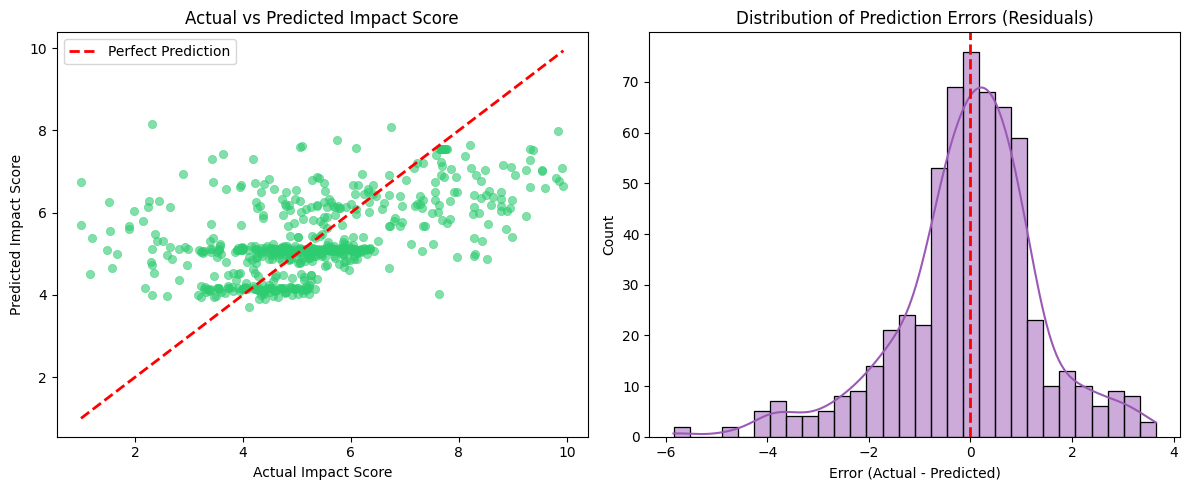

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 5))

# 1. Actual vs Predicted Scatter Plot
plt.subplot(1, 2, 1)
sns.scatterplot(x=true_impact_score, y=pred_impact_score, alpha=0.6, color='#2ecc71', edgecolor=None)
plt.plot([true_impact_score.min(), true_impact_score.max()], [true_impact_score.min(), true_impact_score.max()], 'r--', lw=2, label='Perfect Prediction')
plt.title('Actual vs Predicted Impact Score', fontsize=12)
plt.xlabel('Actual Impact Score')
plt.ylabel('Predicted Impact Score')
plt.legend()

# 2. Residual (Error) Distribution
plt.subplot(1, 2, 2)
residuals = true_impact_score - pred_impact_score
sns.histplot(residuals, kde=True, color='#9b59b6', bins=30)
plt.title('Distribution of Prediction Errors (Residuals)', fontsize=12)
plt.xlabel('Error (Actual - Predicted)')
plt.axvline(0, color='red', linestyle='--', lw=2)

plt.tight_layout()
plt.show()

## Model Explainability (SHAP)
To build trust with the Traffic Police and Hackathon Judges, we use **SHAP (SHapley Additive exPlanations)** to peak inside the 'black box' and understand exactly *why* the AI predicts a severe congestion impact.

Generating SHAP Summary Plot...


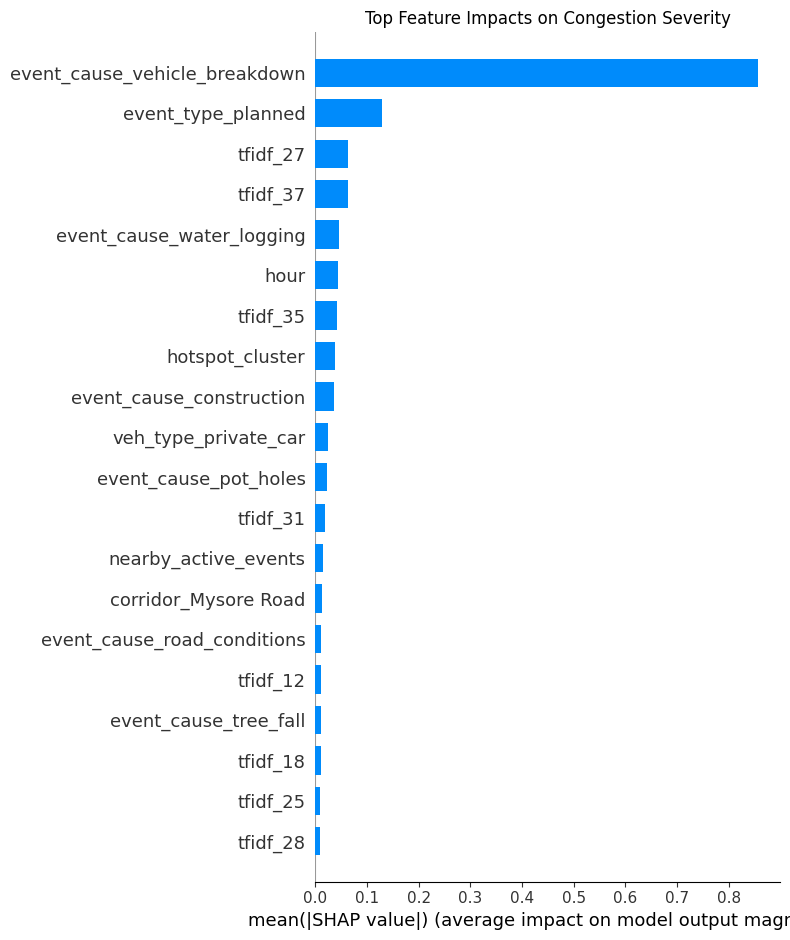

In [8]:
import shap
import matplotlib.pyplot as plt

# Initialize JavaScript visualizations in notebook
shap.initjs()

# Note: A unified VotingRegressor does not support TreeExplainer directly,
# so we explain the RandomForest component (model.estimators_[1]) as a stable proxy
# for feature importance in the ensemble.
explainer = shap.TreeExplainer(model.estimators_[1])
shap_values = explainer.shap_values(X_test)

# Plot the summary
print("Generating SHAP Summary Plot...")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title("Top Feature Impacts on Congestion Severity")
plt.tight_layout()
plt.show()

## Resource Recommendation Matrix
Based on the predicted `Impact_Score`, we will dynamically prescribe resource deployment rules for the Traffic Police.


In [9]:
def recommend_resources(impact_score, requires_closure):
    # Base allocations based on severity
    if impact_score >= 8.0:
        manpower = 5
        barricades = 15
        diversion = "Major Radius Diversion Required (Deploy Advanced Warning Signs)"
    elif impact_score >= 5.0:
        manpower = 3
        barricades = 6
        diversion = "Local Intersection Block Diversion"
    else:
        manpower = 1
        barricades = 2
        diversion = "Minor Disturbance - No Formal Diversion"
        
    # Multiplier rules for physical road blocks
    if requires_closure:
        manpower += 2
        barricades += 10
        diversion += " + Total Road Closure Implementation"
        
    return manpower, barricades, diversion

print("--- AI PREDICTION & PRESCRIPTION SIMULATION ---")
# Simulate live deployment recommendations on 5 random events
sample_indices = X_test.sample(5, random_state=42).index
for idx in sample_indices:
    pred_log_dur = model.predict(X_test.loc[[idx]])[0]
    pred_dur = np.expm1(pred_log_dur)
    
    p_score = X_test.loc[idx, 'priority_score']
    c_mult = X_test.loc[idx, 'closure_multiplier']
    closure = df.loc[idx, 'requires_road_closure']
    cause = df.loc[idx, 'event_cause']
    
    pred_raw_impact = pred_dur * p_score * c_mult
    pred_log_impact = np.log1p(pred_raw_impact)
    
    pred_impact_score = 1.0 + 9.0 * ((pred_log_impact - min_impact) / (max_impact - min_impact + 1e-9))
    pred_impact_score = np.clip(pred_impact_score, 1.0, 10.0)
    
    m, b, d = recommend_resources(pred_impact_score, closure)
    
    print(f"Incident: {str(cause).upper()} | Closure Required: {closure}")
    print(f"Predicted Impact Score: {pred_impact_score:.2f}/10.0 (Predicted Duration: {pred_dur:.1f} mins)")
    print(f"RECOMMENDATION -> Personnel: {m} | Barricades: {b}")
    print(f"DIVERSION PLAN -> {d}")
    print("-" * 50)

--- AI PREDICTION & PRESCRIPTION SIMULATION ---
Incident: TREE_FALL | Closure Required: False
Predicted Impact Score: 6.33/10.0 (Predicted Duration: 157.1 mins)
RECOMMENDATION -> Personnel: 3 | Barricades: 6
DIVERSION PLAN -> Local Intersection Block Diversion
--------------------------------------------------
Incident: OTHERS | Closure Required: True
Predicted Impact Score: 6.51/10.0 (Predicted Duration: 128.6 mins)
RECOMMENDATION -> Personnel: 5 | Barricades: 16
DIVERSION PLAN -> Local Intersection Block Diversion + Total Road Closure Implementation
--------------------------------------------------
Incident: POT_HOLES | Closure Required: False
Predicted Impact Score: 4.73/10.0 (Predicted Duration: 75.1 mins)
RECOMMENDATION -> Personnel: 1 | Barricades: 2
DIVERSION PLAN -> Minor Disturbance - No Formal Diversion
--------------------------------------------------
Incident: VEHICLE_BREAKDOWN | Closure Required: False
Predicted Impact Score: 5.03/10.0 (Predicted Duration: 35.3 mins)
REC

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error

# Predict mean log duration from training set
mean_log_dur = np.mean(y_train)
naive_pred_log_dur = np.full_like(y_test, mean_log_dur)

# Convert to raw duration
naive_pred_dur = np.expm1(naive_pred_log_dur)

# Calculate downstream impact score for naive baseline
naive_pred_raw_impact = naive_pred_dur * y_test_priority * y_test_closure
naive_pred_log_impact = np.log1p(naive_pred_raw_impact)

# Scale to 1.0 - 10.0 using min_impact / max_impact
naive_pred_impact_score = 1.0 + 9.0 * ((naive_pred_log_impact - min_impact) / (max_impact - min_impact + 1e-9))
naive_pred_impact_score = np.clip(naive_pred_impact_score, 1.0, 10.0)

# Evaluate naive baseline
naive_impact_mae = mean_absolute_error(true_impact_score, naive_pred_impact_score)
print(f"Naive Baseline (Mean Prediction) MAE: {naive_impact_mae:.3f}")

# Improvement of V3 over Naive Baseline
improvement = (naive_impact_mae - impact_mae) / naive_impact_mae * 100
print(f"V3 Improvement over Naive Baseline: {improvement:.1f}%")
